# Development of a CNN Model with the Spectogram as it's input feature:

## Imports:

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [3]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## Geral:

In [4]:
BATCH_SIZE = 32
SAMPLE_RATE = 16000
DURATION_SECONDS = 1
N_FFT = 2048
HOP_LENGTH = 512

AUDIO_SAMPLES = DURATION_SECONDS * SAMPLE_RATE

In [5]:
def load_audio(file_path):
    """Carrega um arquivo de áudio e o decodifica para um tensor."""
    audio_binary = tf.io.read_file(file_path)
    audio, _ = tf.audio.decode_wav(audio_binary, desired_channels=1)
    return tf.squeeze(audio, axis=-1)

def ensure_fixed_length(audio, desired_samples=AUDIO_SAMPLES):
    """Garante que o áudio tenha um comprimento fixo."""
    audio_shape = tf.shape(audio)[0]
    if audio_shape < desired_samples:
        padding = desired_samples - audio_shape
        audio = tf.pad(audio, [[0, padding]])
    elif audio_shape > desired_samples:
        audio = audio[:desired_samples]
    return audio

def get_spectrogram(audio):
    """Converte o áudio em um espectrograma."""
    stft = tf.signal.stft(audio, frame_length=N_FFT, frame_step=HOP_LENGTH)
    spectrogram = tf.abs(stft)
    spectrogram = tf.expand_dims(spectrogram, axis=-1)
    return spectrogram

def get_label(file_path, class_names):
    """Extrai o rótulo do caminho do arquivo."""
    parts = tf.strings.split(file_path, os.path.sep)
    return tf.where(parts[-2] == class_names)[0][0]

def process_path(file_path, class_names):
    """Função completa que combina todo o pré-processamento."""
    label = get_label(file_path, class_names)
    audio = load_audio(file_path)
    audio = ensure_fixed_length(audio)
    spectrogram = get_spectrogram(audio)
    return spectrogram, label

def create_dataset_from_dir(directory_path, shuffle=False):

    file_dataset = tf.data.Dataset.list_files(str(Path(directory_path) / '*' / '*.wav'), shuffle=shuffle)
    
    num_files = len(list(file_dataset))
    print(f"Encontrados {num_files} arquivos em: {directory_path}")

    dataset = file_dataset.map(lambda x: process_path(x, CLASS_NAMES), num_parallel_calls=tf.data.AUTOTUNE)
    
    dataset = dataset.cache()
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    
    return dataset

## No Data Augmentation:

In [ ]:
BASE_PATH = "../dataset/"

TRAIN_PATH = os.path.join(BASE_PATH, "train")
VAL_PATH = os.path.join(BASE_PATH, "validation")
TEST_PATH = os.path.join(BASE_PATH, "test")

In [ ]:
CLASS_NAMES = np.array([item.name for item in Path(TRAIN_PATH).glob('*') if item.is_dir()])
    
print(f"Classes encontradas: {CLASS_NAMES}")
NUM_CLASSES = len(CLASS_NAMES)

In [ ]:
train_ds = create_dataset_from_dir(TRAIN_PATH, shuffle=True)
val_ds = create_dataset_from_dir(VAL_PATH)
test_ds = create_dataset_from_dir(TEST_PATH)

for spectrograms, labels in train_ds.take(1):
    input_shape = spectrograms.shape[1:]
    print(f"\nFormato (shape) do lote de espectrogramas: {spectrograms.shape}")
    print(f"Formato (shape) do lote de rótulos: {labels.shape}")
    
    plt.figure(figsize=(10, 4))
    plt.imshow(tf.math.log(spectrograms[0, :, :, 0] + 1e-6).numpy().T, aspect='auto', origin='lower')
    plt.title(f"Espectrograma (Classe: {CLASS_NAMES[labels[0]]})")
    plt.ylabel("Frequência")
    plt.xlabel("Tempo")
    plt.colorbar(format='%+2.0f dB')
    plt.show()
    break

### Training:

In [ ]:
model_espectograma = tf.keras.models.Sequential([
    tf.keras.layers.Input(input_shape),
    tf.keras.layers.Conv2D(32, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(128, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(7, activation='softmax')
])

model_espectograma.summary()

In [ ]:
model_espectograma.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

In [ ]:
history = model_espectograma.fit(train_ds, validation_data=val_ds, callbacks = callbacks, epochs=100, batch_size=32, verbose=1)

### Testing and Results:

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'o-', label='Acurácia de Treino')
plt.plot(epochs_range, val_acc, 'o-', label='Acurácia de Validação')
plt.title('Acurácia de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.grid(True)
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'o-', label='Loss de Treino')
plt.plot(epochs_range, val_loss, 'o-', label='Loss de Validação')
plt.title('Perda (Loss) de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
y_pred_probs = model_espectograma.predict(test_ds)

y_pred_indices = np.argmax(y_pred_probs, axis=1)

# Extract true labels from test_ds
y_true_indices = []
for _, labels in test_ds:
	y_true_indices.extend(labels.numpy())
y_true_indices = np.array(y_true_indices)

In [ ]:
print("--- Relatório de Classificação ---")

# Gera o relatório com precisão, recall, f1-score e suporte
# Usa os nomes das classes do label_encoder treinado anteriormente
report = classification_report(y_true_indices, y_pred_indices, target_names=CLASS_NAMES)

print(report)

In [ ]:
print("--- Matriz de Confusão ---")

# Calcula a matriz de confusão
cm = confusion_matrix(y_true_indices, y_pred_indices)

# Plota a matriz de confusão usando um heatmap do Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,          # Mostra os números dentro das células
    fmt='d',             # Formata os números como inteiros
    cmap='Blues',        # Esquema de cores
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title('Matriz de Confusão')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.show()

## With Data Augmentation:

In [6]:
BASE_PATH = "../dataset_augmented/"

TRAIN_PATH = os.path.join(BASE_PATH, "train")
VAL_PATH = os.path.join(BASE_PATH, "validation")
TEST_PATH = os.path.join(BASE_PATH, "test")

In [7]:
CLASS_NAMES = np.array([item.name for item in Path(TRAIN_PATH).glob('*') if item.is_dir()])
    
print(f"Classes encontradas: {CLASS_NAMES}")
NUM_CLASSES = len(CLASS_NAMES)

Classes encontradas: ['on' 'off' 'go' '_unknown_' 'no' 'stop' '_silence_']


I0000 00:00:1758767764.631182   11588 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1251 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:01:00.0, compute capability: 8.9
2025-09-24 23:36:07.166712: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Encontrados 101370 arquivos em: ../dataset_augmented/train


2025-09-24 23:36:07.770416: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Encontrados 27355 arquivos em: ../dataset_augmented/validation
Encontrados 2890 arquivos em: ../dataset_augmented/test

Formato (shape) do lote de espectrogramas: (32, 28, 1025, 1)
Formato (shape) do lote de rótulos: (32,)


2025-09-24 23:36:08.076037: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


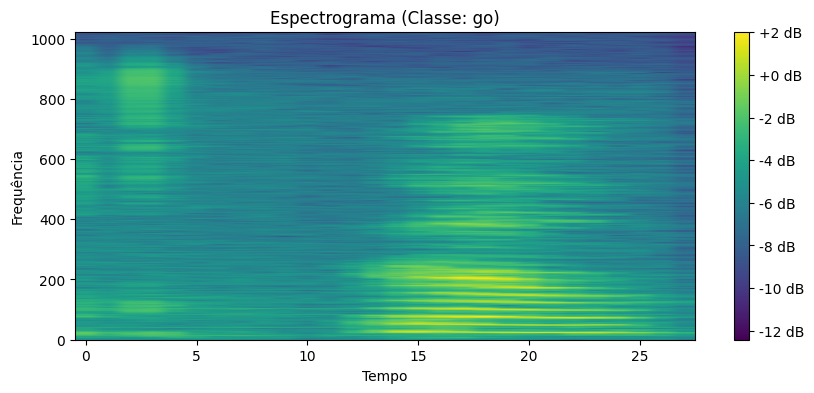

In [8]:
train_ds = create_dataset_from_dir(TRAIN_PATH, shuffle=True)
val_ds = create_dataset_from_dir(VAL_PATH)
test_ds = create_dataset_from_dir(TEST_PATH)

for spectrograms, labels in train_ds.take(1):
    input_shape = spectrograms.shape[1:]
    print(f"\nFormato (shape) do lote de espectrogramas: {spectrograms.shape}")
    print(f"Formato (shape) do lote de rótulos: {labels.shape}")
    
    plt.figure(figsize=(10, 4))
    plt.imshow(tf.math.log(spectrograms[0, :, :, 0] + 1e-6).numpy().T, aspect='auto', origin='lower')
    plt.title(f"Espectrograma (Classe: {CLASS_NAMES[labels[0]]})")
    plt.ylabel("Frequência")
    plt.xlabel("Tempo")
    plt.colorbar(format='%+2.0f dB')
    plt.show()
    break

### Training:

In [9]:
model_espectograma_aug = tf.keras.models.Sequential([
    tf.keras.layers.Input(input_shape),
    tf.keras.layers.Conv2D(32, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(128, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(7, activation='softmax')
])

model_espectograma_aug.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 1025, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 1025, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 512, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 512, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 512, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 256, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 256, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 256, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 128, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,166,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,428,615 (97.00 MB)

 Trainable params: 25,426,375 (96.99 MB)

 Non-trainable params: 2,240 (8.75 KB)

In [10]:
model_espectograma_aug.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [11]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

In [12]:
history = model_espectograma_aug.fit(train_ds, validation_data=val_ds, callbacks = callbacks, epochs=100, batch_size=BATCH_SIZE, verbose=1)

Epoch 1/100


I0000 00:00:1758767780.852799   11767 service.cc:152] XLA service 0x7dfd88008c60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758767780.852816   11767 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070, Compute Capability 8.9
2025-09-24 23:36:20.904406: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1758767781.158665   11767 cuda_dnn.cc:529] Loaded cuDNN version 91002


   7/3168 ━━━━━━━━━━━━━━━━━━━━ 1:00 19ms/step - accuracy: 0.1723 - loss: 2.7589

I0000 00:00:1758767784.306284   11767 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3168/3168 ━━━━━━━━━━━━━━━━━━━━ 79s 23ms/step - accuracy: 0.6863 - loss: 0.8537 - val_accuracy: 0.7777 - val_loss: 0.5759
Epoch 2/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 65s 20ms/step - accuracy: 0.7946 - loss: 0.5660 - val_accuracy: 0.7945 - val_loss: 0.5596
Epoch 3/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 59s 19ms/step - accuracy: 0.8381 - loss: 0.4477 - val_accuracy: 0.8368 - val_loss: 0.4451
Epoch 4/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 59s 19ms/step - accuracy: 0.8687 - loss: 0.3664 - val_accuracy: 0.8668 - val_loss: 0.3973
Epoch 5/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 59s 19ms/step - accuracy: 0.8928 - loss: 0.3036 - val_accuracy: 0.8676 - val_loss: 0.3887
Epoch 6/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 59s 19ms/step - accuracy: 0.9130 - loss: 0.2481 - val_accuracy: 0.8713 - val_loss: 0.3840
Epoch 7/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 59s 19ms/step - accuracy: 0.9272 - loss: 0.2069 - val_accuracy: 0.8732 - val_loss: 0.4205
Epoch 8/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 59s 19ms/step - accuracy: 0.9323 - los

### Testing:

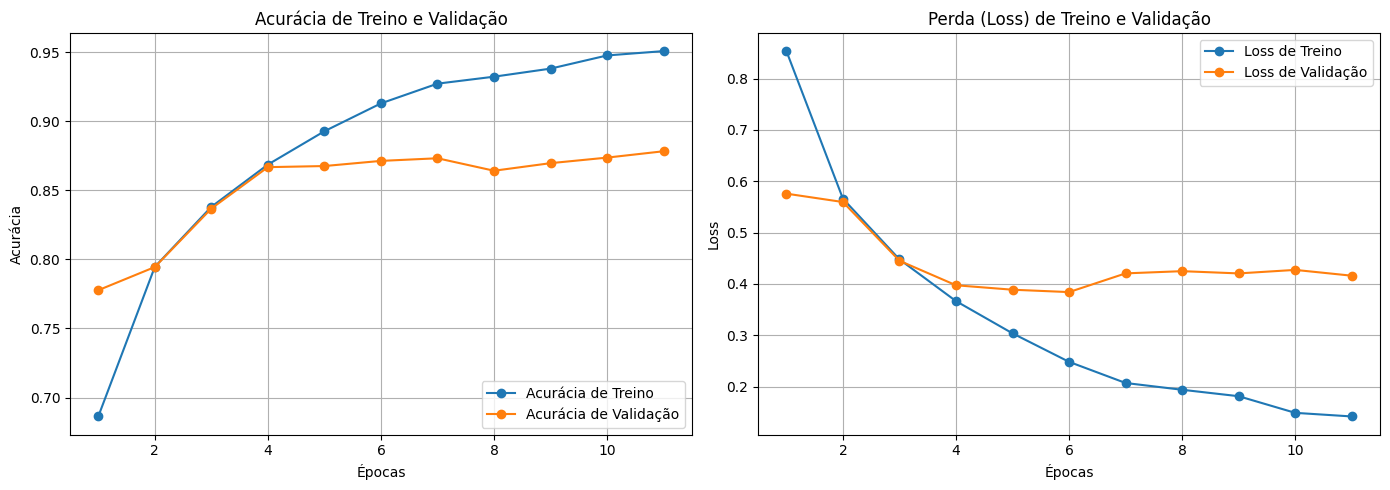

In [13]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'o-', label='Acurácia de Treino')
plt.plot(epochs_range, val_acc, 'o-', label='Acurácia de Validação')
plt.title('Acurácia de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.grid(True)
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'o-', label='Loss de Treino')
plt.plot(epochs_range, val_loss, 'o-', label='Loss de Validação')
plt.title('Perda (Loss) de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [15]:
y_pred_probs = model_espectograma_aug.predict(test_ds)

y_pred_indices = np.argmax(y_pred_probs, axis=1)

# Extract true labels from test_ds
y_true_indices = []
for _, labels in test_ds:
	y_true_indices.extend(labels.numpy())
y_true_indices = np.array(y_true_indices)

91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


2025-09-24 23:48:15.169037: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [16]:
print("--- Relatório de Classificação ---")

# Gera o relatório com precisão, recall, f1-score e suporte
# Usa os nomes das classes do label_encoder treinado anteriormente
report = classification_report(y_true_indices, y_pred_indices, target_names=CLASS_NAMES)

print(report)

--- Relatório de Classificação ---
              precision    recall  f1-score   support

          on       0.90      0.78      0.84       396
         off       0.87      0.82      0.84       402
          go       0.80      0.81      0.80       402
   _unknown_       0.68      0.83      0.75       466
          no       0.86      0.78      0.82       405
        stop       0.89      0.93      0.91       411
   _silence_       0.99      0.96      0.98       408

    accuracy                           0.84      2890
   macro avg       0.86      0.84      0.85      2890
weighted avg       0.85      0.84      0.85      2890



--- Matriz de Confusão ---


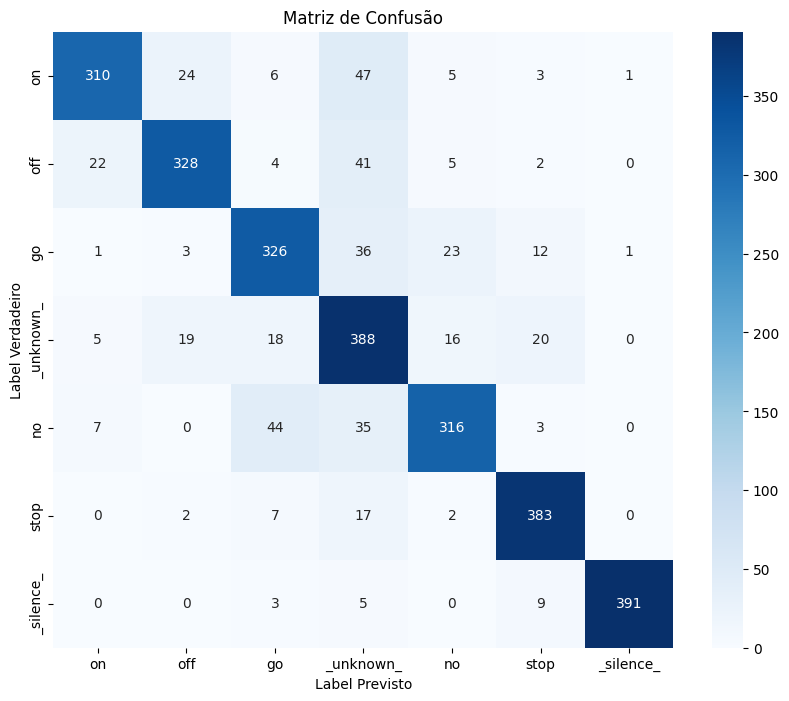

In [17]:
print("--- Matriz de Confusão ---")

# Calcula a matriz de confusão
cm = confusion_matrix(y_true_indices, y_pred_indices)

# Plota a matriz de confusão usando um heatmap do Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,          # Mostra os números dentro das células
    fmt='d',             # Formata os números como inteiros
    cmap='Blues',        # Esquema de cores
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title('Matriz de Confusão')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.show()

In [19]:
model_espectograma_aug.save("../models/model_espectograma_aug.keras")